In [121]:
# - driver
# - CUDA Toolkit
# - cuDNN 
# - PyTorch

In [122]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
# from sklearn.preprocessing import StandardScaler

In [123]:
csv_path = Path(r'C:\Users\user\Desktop\div\data\files\housing.csv')
df = pd.read_csv(csv_path)
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


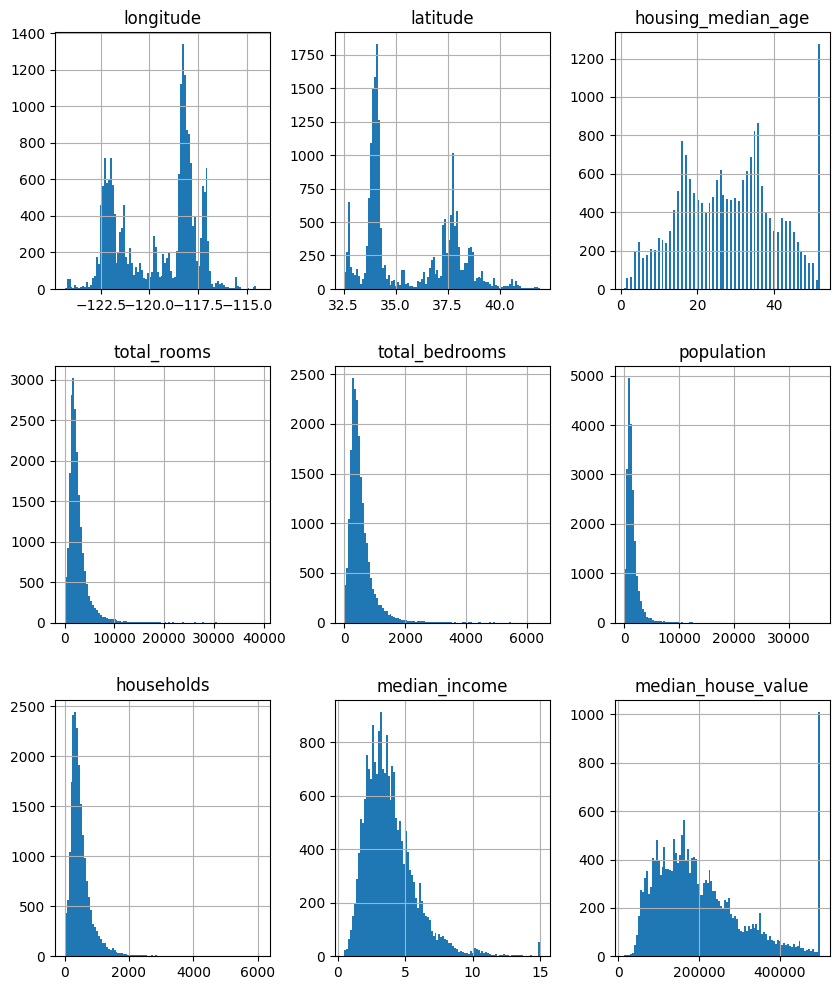

In [124]:
df.select_dtypes(include='number').hist(bins=100, figsize=(10,12));

In [125]:
# m, s = df['total_rooms'].mean(), df['total_rooms'].std()
# # outlier_mask = df['total_rooms'] > m + 3*s
# # df[~outlier_mask]
# # np.log(df['total_rooms'].clip(upper = m + 3*s)).hist(bins=100)
# np.log(df['total_rooms']+1).hist(bins=100)

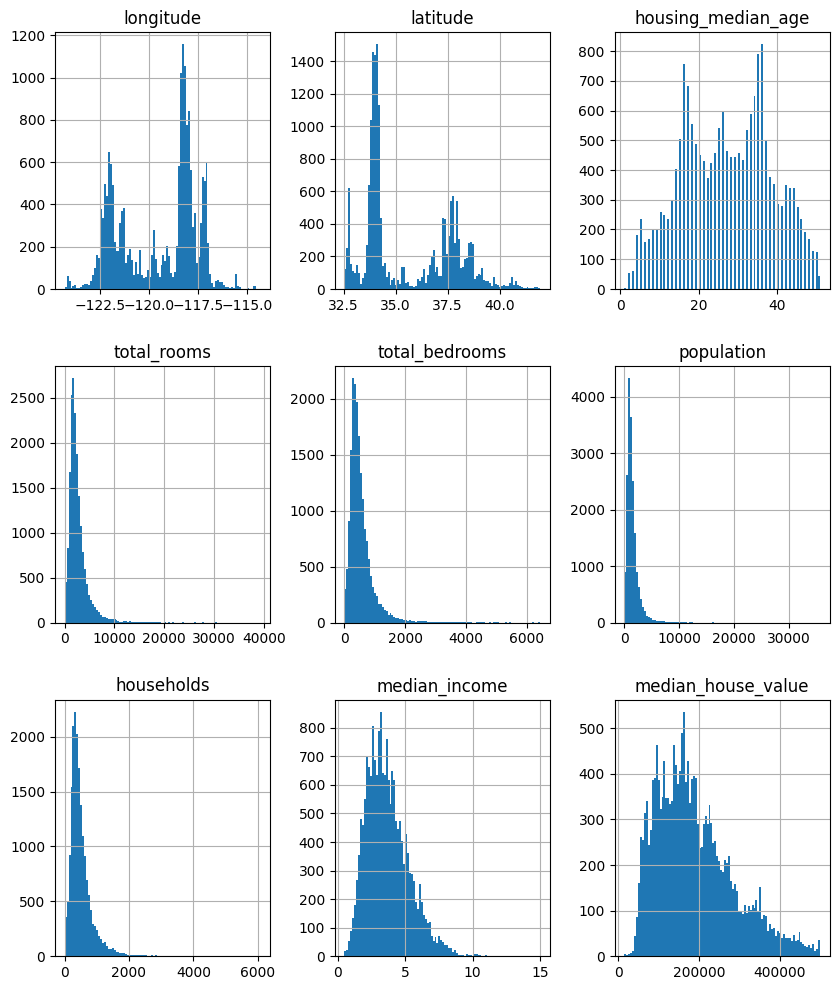

In [126]:
to_delete1 = df['median_house_value'] == df['median_house_value'].max()
to_delete2 = df['housing_median_age'] == df['housing_median_age'].max()

# df.loc[~(to_delete1 | to_delete2) , :]
df = df.loc[~to_delete1 & ~to_delete2 , :]
df.select_dtypes(include='number').hist(bins=100, figsize=(10,12));

In [127]:
cols_for_outliers = df.select_dtypes('number').columns[-6:]

In [128]:
q1 = df[cols_for_outliers].quantile(0.25)
q3 = df[cols_for_outliers].quantile(0.75)
iqr = q3 - q1
upper_limit = q3 + iqr * 4
lower_limit = q1 - iqr * 4

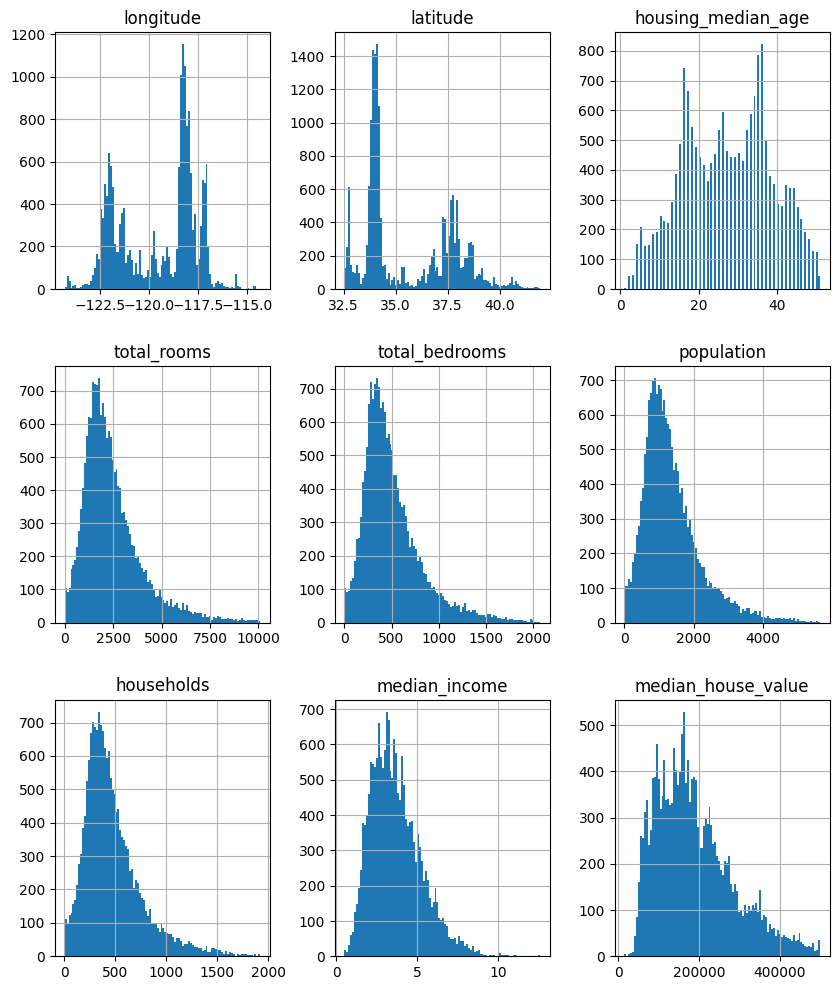

In [129]:
upper_outlier = df[cols_for_outliers] > upper_limit
lower_outlier = df[cols_for_outliers] < lower_limit
outliers = upper_outlier.any(axis=1) | lower_outlier.any(axis=1)
df.loc[~outliers, :].select_dtypes(include='number').hist(bins=100, figsize=(10,12));

In [130]:
df.loc[~outliers, :].shape[0] / df.shape[0]

0.9812621150118458

In [131]:
df = df.loc[~outliers, :]
df.head(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY


In [132]:
# csv_path = Path(r'C:\Users\user\Desktop\div\data\files\housing.csv')
# df = pd.read_csv(csv_path)

# from sklearn.ensemble import IsolationForest
# iso_f = IsolationForest()
# iso_f.fit(df.loc[:, cols_for_outliers])
# outlier_pred = iso_f.predict(df.loc[:, cols_for_outliers])
# outlier_pred

In [133]:
# outlier_mask = (outlier_pred == -1)
# df.loc[~outlier_mask, :].select_dtypes(include='number').hist(bins=100, figsize=(10,12));

In [156]:
df.reset_index(inplace=True, drop=True)
df.head(3)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY


In [159]:
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

y

0        452600.0
1        358500.0
2        226700.0
3        140000.0
4        158700.0
           ...   
18219     78100.0
18220     77100.0
18221     92300.0
18222     84700.0
18223     89400.0
Name: median_house_value, Length: 18224, dtype: float64

In [155]:
# # df['total_bedrooms'].fillna(df['total_bedrooms'].median()).hist(bins=100)
# df['total_bedrooms'].ffill().loc[120:130]

In [160]:
2800/3000

0.9333333333333333